<a href="https://colab.research.google.com/github/ivyyyyy2002-svg/metronome-app/blob/sf2/evaluation/timing/metronome_app_sound_accuracy_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Per-recording results
           file  bpm  beats_used  outliers_removed  nominal_ms  measured_ms  error_ms  error_pct  jitter_sd_ms
120bpm_long.wav  120        1203                14       500.0       500.00     -0.00    -0.0008          9.39
120bpm_run1.wav  120         133                 1       500.0       500.04      0.04     0.0081         10.33
120bpm_run2.wav  120         120                 3       500.0       500.00      0.00     0.0002          9.63
120bpm_run3.wav  120         115                 5       500.0       499.98     -0.02    -0.0040          8.40
240bpm_run1.wav  240         241                 2       250.0       250.00      0.00     0.0008          9.07
240bpm_run2.wav  240         239                 1       250.0       250.00     -0.00    -0.0005          9.83
240bpm_run3.wav  240         237                 4       250.0       250.00      0.00     0.0013          9.01
 60bpm_run1.wav   60          59                 0      1000.0       999.99     -0.01    -

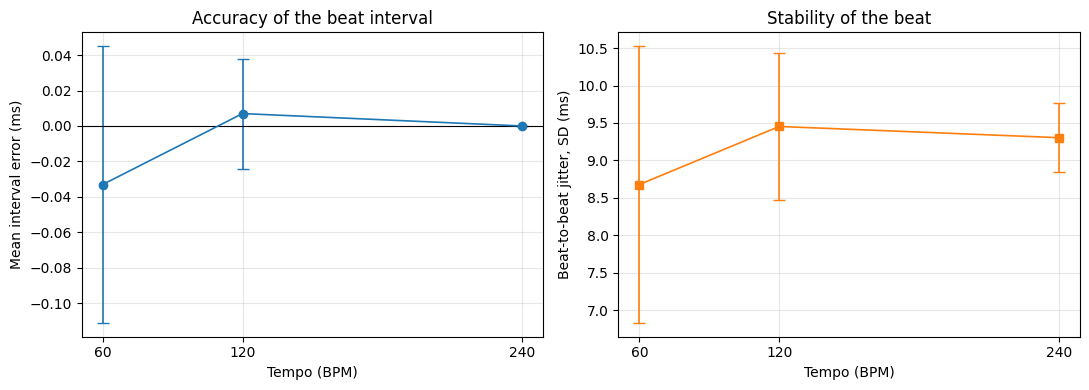

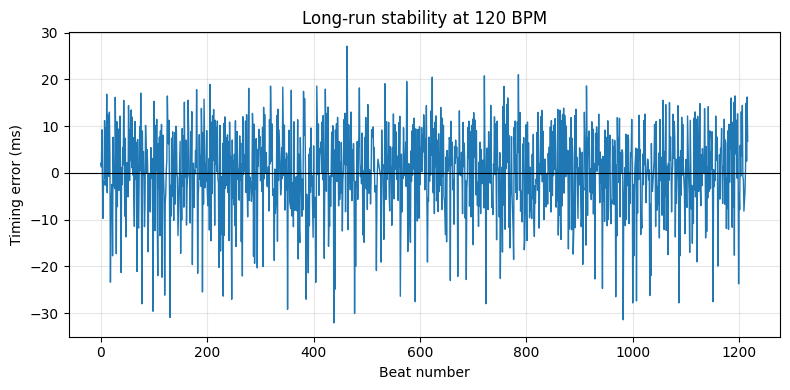

In [5]:
!pip -q install librosa

import re, glob
import librosa, numpy as np, pandas as pd, matplotlib.pyplot as plt

audio_files = sorted(f for f in glob.glob('*.wav')
                     if re.search(r'\d+\s*bpm', f, re.IGNORECASE))


def detect_beats(y, sr, T):
    raw = librosa.onset.onset_detect(y=y, sr=sr, units='time', backtrack=True,
                                 delta=0.3, hop_length=128)
    kept = [raw[0]]
    for t in raw[1:]:
        if t - kept[-1] >= 0.6 * T:
            kept.append(t)
    return np.array(kept)


def trim_stray(onsets, T):
    while len(onsets) > 2 and (onsets[1] - onsets[0]) > 1.5 * T:
        onsets = onsets[1:]
    while len(onsets) > 2 and (onsets[-1] - onsets[-2]) > 1.5 * T:
        onsets = onsets[:-1]
    return onsets


def fit(onsets, n):
    """Least-squares fit t = a + b*n. Returns slope and residuals in ms."""
    A = np.vstack([np.ones_like(n, dtype=float), n]).T
    a, b = np.linalg.lstsq(A, onsets, rcond=None)[0]
    return b, (onsets - (a + b * n)) * 1000


def analyse(fname):
    bpm = int(re.search(r'(\d+)\s*bpm', fname, re.IGNORECASE).group(1))
    T = 60.0 / bpm

    y, sr = librosa.load(fname, sr=None, mono=True)
    onsets = trim_stray(detect_beats(y, sr, T), T)
    n = np.round((onsets - onsets[0]) / T).astype(int)

    b, residual = fit(onsets, n)

    # ---- Robust outlier rejection (median absolute deviation) ----
    med = np.median(residual)
    mad = np.median(np.abs(residual - med))
    scale = 1.4826 * mad
    keep = np.abs(residual - med) <= 3.5 * scale if scale > 0 else np.ones_like(residual, bool)
    n_removed = int((~keep).sum())

    # ---- Refit on the clean points ----
    onsets, n = onsets[keep], n[keep]
    b, residual = fit(onsets, n)

    return {
        'file': fname,
        'bpm': bpm,
        'beats_used': len(onsets),
        'outliers_removed': n_removed,
        'nominal_ms': round(T * 1000, 2),
        'measured_ms': round(b * 1000, 2),
        'error_ms': round(b * 1000 - T * 1000, 2),
        'error_pct': round((b - T) / T * 100, 4),
        'jitter_sd_ms': round(residual.std(ddof=1), 2),
        '_n': n, '_residual': residual,
    }


results = [analyse(f) for f in audio_files]

df = pd.DataFrame(results).drop(columns=['_n', '_residual'])
print("Per-recording results")
print(df.to_string(index=False))
df.to_csv('timing_results_per_run.csv', index=False)

# ---- Average the three runs at each tempo ----
df['is_long'] = df['file'].str.contains('long', case=False)
short = df[~df['is_long']]

summary = (short.groupby('bpm')
           .agg(runs=('file', 'count'),
                nominal_ms=('nominal_ms', 'first'),
                measured_ms=('measured_ms', 'mean'),
                error_ms=('error_ms', 'mean'),
                error_ms_sd=('error_ms', 'std'),
                error_pct=('error_pct', 'mean'),
                jitter_ms=('jitter_sd_ms', 'mean'),
                jitter_ms_sd=('jitter_sd_ms', 'std'))
           .round(3).reset_index())
print("\nSummary by tempo (mean of 3 runs)")
print(summary.to_string(index=False))
summary.to_csv('timing_summary_by_tempo.csv', index=False)

# ---- Figure: accuracy compared across tempos ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].errorbar(summary['bpm'], summary['error_ms'], yerr=summary['error_ms_sd'],
               marker='o', capsize=4, lw=1.2)
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_xlabel('Tempo (BPM)')
ax[0].set_ylabel('Mean interval error (ms)')
ax[0].set_title('Accuracy of the beat interval')
ax[0].set_xticks(summary['bpm'])
ax[0].grid(alpha=0.3)

ax[1].errorbar(summary['bpm'], summary['jitter_ms'], yerr=summary['jitter_ms_sd'],
               marker='s', capsize=4, lw=1.2, color='tab:orange')
ax[1].set_xlabel('Tempo (BPM)')
ax[1].set_ylabel('Beat-to-beat jitter, SD (ms)')
ax[1].set_title('Stability of the beat')
ax[1].set_xticks(summary['bpm'])
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('timing_accuracy_by_tempo.png', dpi=200)
plt.show()

# ---- Figure: long-run drift ----
for r in results:
    if 'long' in r['file'].lower():
        plt.figure(figsize=(8, 4))
        plt.plot(r['_n'], r['_residual'], lw=1)
        plt.axhline(0, color='k', lw=0.8)
        plt.xlabel('Beat number'); plt.ylabel('Timing error (ms)')
        plt.title(f"Long-run stability at {r['bpm']} BPM")
        plt.grid(alpha=0.3); plt.tight_layout()
        plt.savefig(f"timing_drift_long_{r['bpm']}bpm.png", dpi=200)
        plt.show()